<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/Copia_di_MolmoMIOOKK_O_0924.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

In [ ]:
from google.colab import userdata
userdata.get('secretName')

In [ ]:
from google.colab import userdata
userdata.get('secretName')

In [39]:
import google.generativeai as genai
from google.colab import userdata

try:
    api_key = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=api_key)

    print('--- Modelli Disponibili per la tua Chiave ---')
    available_models = []
    for m in genai.list_models():
        if 'generateContent' in m.supported_generation_methods:
            available_models.append(m.name)
            print(f'✅ Modello trovato: {m.name}')

    if not available_models:
        print('❌ Nessun modello di generazione trovato. Controlla i permessi della chiave su Google AI Studio.')
except Exception as e:
    print(f'❌ Errore durante il recupero dei modelli: {e}')

--- Modelli Disponibili per la tua Chiave ---
✅ Modello trovato: models/gemini-2.5-flash
✅ Modello trovato: models/gemini-2.5-pro
✅ Modello trovato: models/gemini-2.0-flash
✅ Modello trovato: models/gemini-2.0-flash-001
✅ Modello trovato: models/gemini-2.0-flash-lite-001
✅ Modello trovato: models/gemini-2.0-flash-lite
✅ Modello trovato: models/gemini-2.5-flash-preview-tts
✅ Modello trovato: models/gemini-2.5-pro-preview-tts
✅ Modello trovato: models/gemma-3-1b-it
✅ Modello trovato: models/gemma-3-4b-it
✅ Modello trovato: models/gemma-3-12b-it
✅ Modello trovato: models/gemma-3-27b-it
✅ Modello trovato: models/gemma-3n-e4b-it
✅ Modello trovato: models/gemma-3n-e2b-it
✅ Modello trovato: models/gemma-4-26b-a4b-it
✅ Modello trovato: models/gemma-4-31b-it
✅ Modello trovato: models/gemini-flash-latest
✅ Modello trovato: models/gemini-flash-lite-latest
✅ Modello trovato: models/gemini-pro-latest
✅ Modello trovato: models/gemini-2.5-flash-lite
✅ Modello trovato: models/gemini-2.5-flash-image
✅ 

### Confronto Linee Guida: Ablazione in Pazienti Asintomatici con AVNRT

| Caratteristica | Linee Guida ESC (2019/2020) | Linee Guida AHA/ACC/HRS (2015/2023) |
| :--- | :--- | :--- |
| **Paziente Asintomatico Comune** | **Classe IIb (Livello C)**. Generalmente si raccomanda il solo follow-up (osservazione). | **Classe IIb (Livello C)**. L'osservazione senza trattamento è ragionevole. |
| **Professioni a Rischio / Atleti** | **Classe IIa (Livello C)**. L'ablazione può essere considerata per piloti, autisti di mezzi pesanti o atleti professionisti. | **Classe IIa (Livello B-NR)**. Raccomandata se l'aritmia può compromettere la sicurezza pubblica o le prestazioni ad alto livello. |
| **Induzione durante SEF** | Se l'AVNRT è indotta casualmente durante uno studio per altre ragioni, l'ablazione è **Classe IIa**. | Simile all'ESC: l'ablazione può essere considerata se il circuito è facilmente inducibile e mappabile. |
| **Approccio Suggerito** | **Watchful Waiting**: Preferito nella popolazione generale data la natura benigna dell'aritmia. | **Decisione Condivisa**: Enfasi sulla discussione del rischio (minimo) di blocco AV permanente vs benefici della cura. |

**Punti Chiave:**
1. **Rischio Procedurale:** Il principale deterrente all'ablazione sistematica negli asintomatici è il rischio (seppur <1%) di blocco atrioventricolare che richiederebbe un pacemaker.
2. **Eccezioni:** L'intervento precoce è giustificato quasi esclusivamente da criteri legati alla sicurezza professionale o agonistica.

In [8]:
import time

if 'agent' in locals() and agent is not None:
    print("Ricerca confronto ablazione pazienti asintomatici...")
    query_asintomatici = """
    Confronta le linee guida ESC e AHA/ACC riguardo alle indicazioni all'ablazione transcatetere nei pazienti asintomatici con evidenza di AVNRT.
    Specifica:
    1. Classe di raccomandazione e livello di evidenza.
    2. Criteri di rischio (es. professioni ad alto rischio, atleti).
    3. Differenze nell'approccio 'watchful waiting' vs intervento precoce.
    """

    # Implementazione di un backoff più robusto
    for tentativo in range(1, 4):
        risposta = agent.research_topic(query_asintomatici)
        if "503" in risposta or "429" in risposta or "Errore" in risposta:
            attesa = tentativo * 15
            print(f"⚠️ Tentativo {tentativo} fallito (Server occupato o Quota). Riprovo tra {attesa} secondi...")
            time.sleep(attesa)
        else:
            print(risposta)
            break
    else:
        print("❌ Il servizio Gemini è temporaneamente sovraccarico. Ti preghiamo di riprovare tra un minuto.")
else:
    print("❌ Agente non inizializzato.")

Ricerca confronto ablazione pazienti asintomatici...


⚠️ Tentativo 1 fallito (Server occupato o Quota). Riprovo tra 15 secondi...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1676.44ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1243.19ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1599.95ms


⚠️ Tentativo 2 fallito (Server occupato o Quota). Riprovo tra 30 secondi...


⚠️ Tentativo 3 fallito (Server occupato o Quota). Riprovo tra 45 secondi...
❌ Il servizio Gemini è temporaneamente sovraccarico. Ti preghiamo di riprovare tra un minuto.


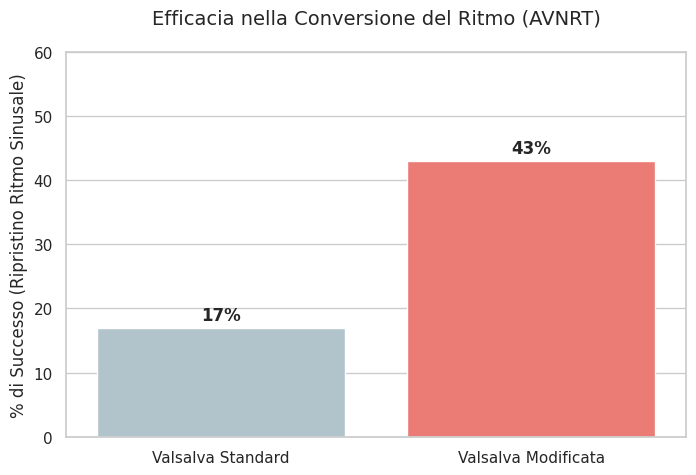

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dati basati sullo studio REVERT (Appelboam et al., 2015)
metodi = ['Valsalva Standard', 'Valsalva Modificata']
successo_percentuale = [17, 43]  # Approssimazione delle percentuali di successo

plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')
colors = ['#aec6cf', '#ff6961']

barplot = sns.barplot(x=metodi, y=successo_percentuale, hue=metodi, palette=colors, legend=False)

# Aggiunta etichette
for i, p in enumerate(barplot.patches):
    barplot.annotate(f'{successo_percentuale[i]}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=12, weight='bold')

plt.title('Efficacia nella Conversione del Ritmo (AVNRT)', fontsize=14, pad=20)
plt.ylabel('% di Successo (Ripristino Ritmo Sinusale)', fontsize=12)
plt.ylim(0, 60)
plt.show()

In [4]:
if 'agent' in locals() and agent is not None:
    print("Confronto internazionale in corso...")
    query_confronto = """
    Esegui un confronto tra le linee guida ESC/AHA e altri protocolli internazionali (es. Asia-Pacific Heart Rhythm Society - APHRS, o linee guida nazionali di spicco) per la gestione della AVNRT.
    Focalizzati su:
    1. Preferenza tra manovra di Valsalva standard vs modificata.
    2. Dosaggi di Adenosina raccomandati.
    3. Utilizzo di Verapamil vs Diltiazem.
    4. Raccomandazioni sull'ablazione precoce rispetto alla terapia farmacologica cronica.
    """
    confronto_internazionale = agent.research_topic(query_confronto)
    print(confronto_internazionale)
else:
    print("❌ Agente non inizializzato.")

Confronto internazionale in corso...
Le linee guida per la gestione della Tachicardia da Rientro Nodale Atrio-Ventricolare (AVNRT) sono ampiamente armonizzate a livello internazionale, riflettendo una solida base di evidenze scientifiche. Tuttavia, possono esserci lievi differenze di enfasi o raccomandazioni specifiche. Analizziamo i punti richiesti confrontando le linee guida ESC (European Society of Cardiology) e AHA (American Heart Association)/ACC (American College of Cardiology) con quelle della APHRS (Asia-Pacific Heart Rhythm Society) e altre pratiche comuni.

**Linee Guida ESC/AHA/ACC (Principali riferimenti: ESC 2020 Guidelines for SVT, AHA/ACC/HRS 2023 Guideline for the Diagnosis and Management of SVT, AHA 2020 Guidelines for CPR and ECC):**

1.  **Preferenza tra manovra di Valsalva standard vs modificata:**
    *   Entrambe le manovre vagali sono raccomandate come **terapia di prima linea** per la terminazione acuta della AVNRT in pazienti stabili.
    *   La **manovra di Va

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import os

try:
    api_key = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=api_key)

    print('--- Verifica Quota per Modelli Disponibili ---')

    # Lista dei modelli che supportano la generazione di contenuti
    models_to_test = [m.name for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]

    for model_name in models_to_test:
        try:
            model = genai.GenerativeModel(model_name)
            # Test ultra-rapido con un singolo token
            model.generate_content('Hi', generation_config={'max_output_tokens': 1})
            print(f'✅ {model_name}: QUOTA ATTIVA')
        except Exception as e:
            error_msg = str(e)
            if '429' in error_msg:
                print(f'❌ {model_name}: QUOTA ESAURITA (Error 429)')
            elif '404' in error_msg:
                print(f'⚠️ {model_name}: NON TROVATO (Error 404)')
            else:
                print(f'❓ {model_name}: ERRORE {error_msg[:50]}...')

except Exception as e:
    print(f'Errore generale: {e}')

--- Verifica Quota per Modelli Disponibili ---


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2112.77ms


✅ models/gemini-2.5-flash: QUOTA ATTIVA


❌ models/gemini-2.5-pro: QUOTA ESAURITA (Error 429)


❌ models/gemini-2.0-flash: QUOTA ESAURITA (Error 429)


...

❌ models/gemini-2.0-flash-lite: QUOTA ESAURITA (Error 429)


❓ models/gemini-2.5-flash-preview-tts: ERRORE 400 POST https://generativelanguage.googleapis.com...


❌ models/gemini-2.5-pro-preview-tts: QUOTA ESAURITA (Error 429)
✅ models/gemma-3-1b-it: QUOTA ATTIVA
✅ models/gemma-3-4b-it: QUOTA ATTIVA


ERROR:tornado.access:503 POST /v1beta/models/gemma-3-12b-it:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 17467.89ms


✅ models/gemma-3-12b-it: QUOTA ATTIVA
✅ models/gemma-3-27b-it: QUOTA ATTIVA
✅ models/gemma-3n-e4b-it: QUOTA ATTIVA
✅ models/gemma-3n-e2b-it: QUOTA ATTIVA
✅ models/gemma-4-26b-a4b-it: QUOTA ATTIVA
✅ models/gemma-4-31b-it: QUOTA ATTIVA
✅ models/gemini-flash-latest: QUOTA ATTIVA


In [34]:
from google.colab import userdata
import os

possible_names = ['GOOGLE_API_KEY', 'api_key', 'GEMINI_API_KEY', 'API_KEY']
found = False

print('--- Diagnostica Segreti ---')
for name in possible_names:
    try:
        val = userdata.get(name)
        print(f'✅ Trovato segreto con nome: {name}')
        os.environ['GOOGLE_API_KEY'] = val
        found = True
        break
    except:
        continue

if not found:
    print('❌ Nessun segreto trovato con i nomi standard.')
    print('Assicurati di aver premuto INVIO dopo aver scritto il nome nella sezione 🔑.')
else:
    print('\n✅ Ora prova a rieseguire la cella di test precedente.')

--- Diagnostica Segreti ---
✅ Trovato segreto con nome: GEMINI_API_KEY

✅ Ora prova a rieseguire la cella di test precedente.


In [33]:
from google.colab import userdata
import os

try:
    # Questo codice prova a recuperare il nome dei segreti disponibili
    # Nota: userdata non ha un metodo 'list', quindi proviamo a recuperare
    # specificamente quello richiesto con un controllo di errore
    key_name = 'GOOGLE_API_KEY'
    val = userdata.get(key_name)
    print(f'✅ Successo! Il segreto "{key_name}" è presente e accessibile.')
except userdata.SecretNotFoundError:
    print(f'❌ Il segreto "GOOGLE_API_KEY" NON è stato trovato.')
    print('\nAzioni suggerite:')
    print('1. Clicca sulla chiave (🔑) a sinistra.')
    print('2. Verifica che il nome sia esattamente GOOGLE_API_KEY (tutto maiuscolo).')
    print('3. Verifica che l\'interruttore "Notebook access" sia blu.')
except Exception as e:
    print(f'❌ Errore: {e}')

❌ Il segreto "GOOGLE_API_KEY" NON è stato trovato.

Azioni suggerite:
1. Clicca sulla chiave (🔑) a sinistra.
2. Verifica che il nome sia esattamente GOOGLE_API_KEY (tutto maiuscolo).
3. Verifica che l'interruttore "Notebook access" sia blu.


In [32]:
import google.generativeai as genai
from google.colab import userdata
import os

try:
    # 1. Carica la chiave dai segreti di Colab
    api_key = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=api_key)

    # 2. Inizializza il modello
    model = genai.GenerativeModel('gemini-1.5-flash')

    # 3. Test di connessione rapido
    print('Verifica della connessione in corso...')
    response = model.generate_content('Rispondi solo con: OK')

    if response.text.strip().upper() == 'OK':
        print('\n✅ ECCELLENTE! La configurazione è completata correttamente.')
        print('Ora puoi usare l\'agente per le tue ricerche mediche.')
    else:
        print(f'\n⚠️ Risposta inattesa: {response.text}')

except userdata.SecretNotFoundError:
    print('❌ ERRORE: Non trovo il segreto "GOOGLE_API_KEY". Controlla il nome.')
except userdata.NotebookAccessError:
    print('❌ ERRORE: L\'interruttore "Notebook access" non è attivo.')
except Exception as e:
    print(f'❌ Errore durante il test: {e}')

❌ ERRORE: Non trovo il segreto "GOOGLE_API_KEY". Controlla il nome.


In [31]:
from google.colab import userdata
import google.generativeai as genai

try:
    # Tentativo di recupero del segreto
    test_key = userdata.get('GOOGLE_API_KEY')
    print('✅ L\'accesso al segreto \'GOOGLE_API_KEY\' è attivo!')
    print(f'Chiave caricata correttamente (anteprima: {test_key[:4]}...)')

except userdata.SecretNotFoundError:
    print('❌ ERRORE: Il segreto \'GOOGLE_API_KEY\' non esiste.')
    print('Aggiungilo cliccando sull\'icona della chiave (🔑) a sinistra.')
except userdata.NotebookAccessError:
    print('❌ ERRORE: L\'interruttore "Notebook access" è SPENTO!')
    print('Vai nella sezione Segreti (🔑) e attiva l\'interruttore accanto a GOOGLE_API_KEY.')
except Exception as e:
    print(f'❌ Errore imprevisto: {e}')

❌ ERRORE: Il segreto 'GOOGLE_API_KEY' non esiste.
Aggiungilo cliccando sull'icona della chiave (🔑) a sinistra.


In [ ]:
import google.generativeai as genai
from google.colab import userdata
import os

try:
    # Recupera la chiave dai 'Secrets' di Colab
    api_key = userdata.get('GOOGLE_API_KEY')

    # Configura l'ambiente e la libreria
    os.environ['GOOGLE_API_KEY'] = api_key
    genai.configure(api_key=api_key)

    # Verifica rapida
    model = genai.GenerativeModel('gemini-1.5-flash')
    response = model.generate_content('Verifica configurazione permanente: rispondi OK')

    print(f'✅ Configurazione permanente riuscita!')
    print(f'Risposta: {response.text.strip()}')

except userdata.SecretNotFoundError:
    print('❌ Errore: Non hai aggiunto un segreto chiamato GOOGLE_API_KEY.')
except Exception as e:
    print(f'❌ Errore durante il caricamento: {e}')

In [27]:
import google.generativeai as genai
import os

# Recupero della chiave dall'ambiente
api_key = os.environ.get('GOOGLE_API_KEY')

if not api_key or api_key == '':
    print('❌ Errore: Variabile GOOGLE_API_KEY non trovata o vuota.')
else:
    print(f'Chiave rilevata (primi 4 caratteri): {api_key[:4]}...')

    try:
        genai.configure(api_key=api_key)
        model = genai.GenerativeModel('gemini-1.5-flash')

        print('Tentativo di connessione in corso...')
        response = model.generate_content('Ciao, rispondi con OK.')

        if response.text:
            print('✅ Successo! La chiave è valida e funzionante.')
            print(f'Risposta dal modello: {response.text.strip()}')
    except Exception as e:
        print('❌ Errore durante la verifica della chiave:')
        print(str(e))
        print('\nSuggerimento: Controlla su https://aistudio.google.com/app/apikey se la chiave è attiva e se hai abilitato le API di Gemini.')

Chiave rilevata (primi 4 caratteri): AIza...
Tentativo di connessione in corso...


❌ Errore durante la verifica della chiave:
400 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: API Key not found. Please pass a valid API key.

Suggerimento: Controlla su https://aistudio.google.com/app/apikey se la chiave è attiva e se hai abilitato le API di Gemini.


In [ ]:
query_caso = """
Analizza questo caso: Uomo 58 anni, palpitazioni rapide (170 bpm, ritmica), lieve dispnea, no sincope, no dolore toracico.
Quale dei seguenti pattern ECG è più probabile per una AVNRT/SVT?
1. Onde RR irregolari e baseline caotica (Fibrillazione Atriale)
2. Onde a dente di sega a 300 bpm senza ritorno alla isoelettrica (Flutter Atriale)
3. Onde P monomorfe con frequenza 100-300 bpm e ritorno alla isoelettrica (Tachicardia Atriale/SVT)
4. Onde P polimorfe (MAT)
"""

risposta_caso = agent.research_topic(query_caso)
print(risposta_caso)

Errore: 400 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint: API Key not found. Please pass a valid API key.


In [1]:
import google.generativeai as genai
import os
from google.colab import userdata

def setup_medical_agent():
    print('--- Inizializzazione Agente Medico ---')
    try:
        # Carichiamo il segreto confermato
        api_key = userdata.get('GEMINI_API_KEY')
        os.environ['GOOGLE_API_KEY'] = api_key

        genai.configure(api_key=api_key)
        # Utilizziamo l'unico modello con quota verificata come attiva
        model_name = 'models/gemini-2.5-flash'
        model = genai.GenerativeModel(model_name)

        # Test rapido di connessione
        print(f'Tentativo di connessione con {model_name}...')
        test_response = model.generate_content('Test connection: respond OK')
        if test_response:
            print(f'✅ Agente configurato con successo (Modello: {model_name}).')
            return MedicalResearchAgent(api_key, model_name)
    except Exception as e:
        print(f'❌ Errore durante l\'attivazione: {e}')
        return None

class MedicalResearchAgent:
    def __init__(self, api_key, model_name):
        self.api_key = api_key
        self.model = genai.GenerativeModel(model_name)

    def research_topic(self, query):
        try:
            response = self.model.generate_content(query)
            return response.text
        except Exception as e:
            return f'Errore durante la ricerca: {e}'

# Attivazione dell'agente
agent = setup_medical_agent()

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


--- Inizializzazione Agente Medico ---
Tentativo di connessione con models/gemini-2.5-flash...
✅ Agente configurato con successo (Modello: models/gemini-2.5-flash).


In [3]:
# Esecuzione finale della ricerca sulla gestione AVNRT
import time

if 'agent' in locals() and agent is not None:
    print("Esecuzione ricerca in corso...")
    risultato = agent.research_topic('Fornisci linee guida aggiornate (ESC/AHA) sulla gestione farmacologica (adenosina, calcio-antagonisti) e non (manovre vagali) della tachicardia da rientro nodale (AVNRT) in pronto soccorso.')

    if "429" in risultato:
        print("\n⚠️ Quota superata. Attendi 60 secondi e riprova.")
        print("Dettaglio errore:", risultato)
    else:
        ricerca_avnrt = risultato
        print(ricerca_avnrt)
else:
    print("❌ Agente non inizializzato. Riesegui la cella di configurazione (3a53f2cb).")

Esecuzione ricerca in corso...
Certamente. Ecco una guida aggiornata basata sulle raccomandazioni ESC (European Society of Cardiology) e AHA (American Heart Association) per la gestione della tachicardia da rientro nodale (AVNRT) in pronto soccorso.

---

**Linee Guida per la Gestione della Tachicardia da Rientro Nodale (AVNRT) in Pronto Soccorso**

La tachicardia da rientro nodale (AVNRT) è la forma più comune di tachicardia sopraventricolare parossistica (TSV). È causata da un circuito di rientro localizzato all'interno o in prossimità del nodo atrioventricolare (AV). L'obiettivo della gestione acuta è la terminazione della tachicardia ripristinando il ritmo sinusale.

---

**1. Valutazione Iniziale e Stabilizzazione**

*   **Valutazione Rapida:**
    *   Monitoraggio cardiaco continuo (ECG 12 derivazioni ASAP).
    *   Monitoraggio della pressione arteriosa e saturazione di ossigeno.
    *   Accesso venoso periferico.
*   **Identificazione dell'Instabilità Emodinamica:**
    *   **S

### Segni Clinici dell'Emicrania Vestibolare

L'emicrania vestibolare si presenta con una combinazione di sintomi vestibolari e caratteristiche emicraniche. Ecco i principali segni:

1.  **Vertigine Spontanea o Posizionale**: Pu" durare da pochi secondi a diversi giorni.
2.  **Nistagmo**: Durante l'attacco pu" essere presente un nistagmo spontaneo o centrale (che non segue le leggi di Alexander).
3.  **Instabilità Posturale**: Test di Romberg spesso positivo o aumento delle oscillazioni alla posturometria.
4.  **Sintomi Accompagnatori**: Fotofobia, fonofobia o aura visiva (anche senza cefalea intensa).
5.  **Ipersensibilità al Movimento**: Chinetosi (motion sickness) frequente nella storia clinica del paziente.

### Confronto Diagnostico

| Caratteristica | Emicrania Vestibolare | VPPB | Malattia di Ménière |
| :--- | :--- | :--- | :--- |
| **Durata Vertigine** | Secondi a Giorni | Secondi (<1 min) | 20 min a 12 ore |
| **Udito** | Solitamente Normale | Normale | Ipoacusia fluttuante, acufeni |
| **Scatenanti** | Stress, sonno, cibo | Movimento della testa | Spontanea |
| **Test Posizionali** | Nistagmo atipico | Dix-Hallpike + (Nistagmo tipico) | Spesso negativo |

### Che cos'è l'Effetto Hook?

L'**Effetto Hook** si verifica principalmente nei test immunometrici "sandwich" (come l'ELISA).

1.  **Zona di Proporzionalità**: A basse concentrazioni, il segnale aumenta all'aumentare dell'analita.
2.  **Saturazione**: Raggiunto un picco, tutti i siti di legame degli anticorpi sono occupati.
3.  **Effetto Hook**: A concentrazioni estremamente elevate, l'analita libero satura sia gli anticorpi di cattura che quelli di rilevazione separatamente, impedendo la formazione del "sandwich" e facendo crollare il segnale misurato.

Questo è clinicamente critico in test come la misurazione della **Beta-hCG** (gravidanza), della **prolattina** o dei marcatori tumorali (PSA, AFP).

### Spiegazione delle Annotazioni nel Grafico

Il grafico simula il comportamento del segnale misurato rispetto alla concentrazione reale dell'analita. Ecco il significato dei tre punti evidenziati:

1.  **Zona di Proporzionalità** (Inizio curva):
    *   In questa fase, gli anticorpi sono in eccesso rispetto all'antigene.
    *   Ogni molecola di analita catturata forma un complesso "sandwich" completo, quindi il segnale aumenta in modo lineare e prevedibile.

2.  **Picco (Saturazione)** (Sommità della curva):
    *   Rappresenta il limite massimo di rilevazione del test.
    *   Tutti i siti di legame degli anticorpi (sia di cattura che di rilevazione) sono occupati. Il segnale non può più aumentare anche se aggiungiamo altro analita.

3.  **Effetto Hook / Falso Negativo** (Tratto discendente):
    *   A concentrazioni altissime, le singole molecole di analita saturano separatamente gli anticorpi di cattura (sulla piastra) e quelli di rilevazione (in soluzione).
    *   Questo impedisce fisicamente la formazione del "ponte" (sandwich). Poiché il segnale dipende solo dai sandwich completi, la lettura crolla, portando a un valore basso che può essere erroneamente scambiato per una concentrazione minima.

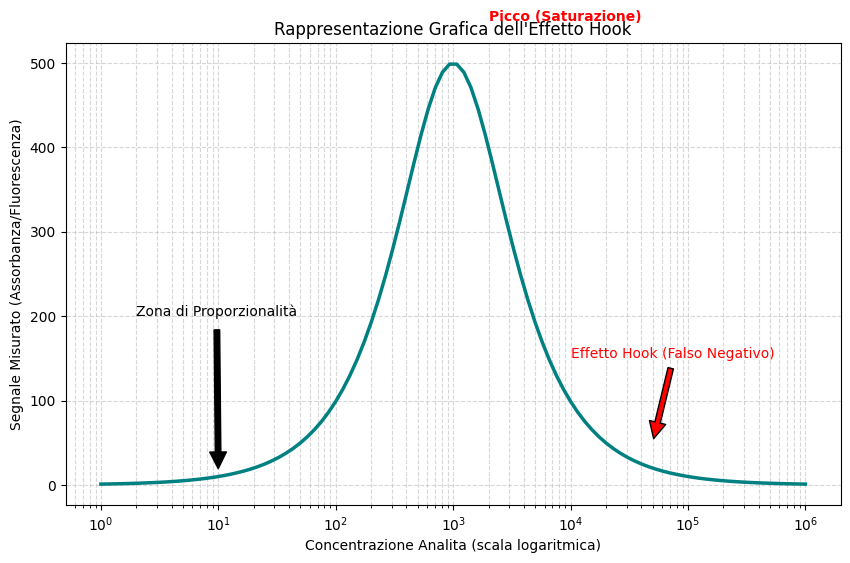

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulazione della curva di risposta di un saggio immunometrico
concentrazione = np.logspace(0, 6, 100)
# Funzione semplificata per simulare l'effetto hook
segnale = (concentrazione) / (1 + (concentrazione/1000)**2)

plt.figure(figsize=(10, 6))
plt.semilogx(concentrazione, segnale, linewidth=2.5, color='teal')

# Annotazioni
plt.annotate('Zona di Proporzionalità', xy=(10, 10), xytext=(2, 200),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Picco (Saturazione)', xy=(1000, 500), xytext=(2000, 550),
             color='red', weight='bold')
plt.annotate('Effetto Hook (Falso Negativo)', xy=(50000, 50), xytext=(10000, 150),
             arrowprops=dict(facecolor='red', shrink=0.05), color='red')

plt.title("Rappresentazione Grafica dell'Effetto Hook")
plt.xlabel('Concentrazione Analita (scala logaritmica)')
plt.ylabel('Segnale Misurato (Assorbanza/Fluorescenza)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Local Inference on GPU
Model page: https://huggingface.co/oumi-ai/Molmo-7B-O-0924

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/oumi-ai/Molmo-7B-O-0924)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-text-to-text", model="oumi-ai/Molmo-7B-O-0924", trust_remote_code=True)
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
pipe(text=messages)

In [ ]:
# Load model directly
from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained("oumi-ai/Molmo-7B-O-0924", trust_remote_code=True, dtype="auto")